# A2 — Cautela e atrasos

**Pergunta de negócio:** quem está com cada material, há quanto tempo, quais devoluções atrasam, e o atraso é da pessoa ou do processo?

**Como os dados são montados:** não existe tabela de cautelas. Cada cautela é reconstruída do histórico imutável pela view `analise.vw_cautela` (migração `0008`): cada retirada de uma unidade é pareada com a movimentação seguinte da mesma unidade pela window function `LEAD` (devolução, "não localizada" ou nada ainda). Estornos saem da sequência antes do pareamento. A data de referência é a última movimentação registrada (31/08/2026, 21h46).

> Dados 100% fictícios (semente 42). O gabarito do gerador só aparece na última seção, para conferir se a análise acertou.

In [1]:
import matplotlib.pyplot as plt
import pandas as pd

from almox.analise import cautela as a2
from almox.banco import engine
from almox.config import carregar_config_banco

pd.set_option("display.width", 160)
banco = engine(carregar_config_banco())
cautelas = a2.ler_cautelas(banco)
turno = a2.resumo_turno(cautelas)
print(
    f"{len(cautelas)} cautelas; {cautelas.atrasada.mean():.1%} devolvidas "
    "depois do prazo (ou ainda fora com o prazo vencido)."
)
print(
    f"Rádios (regime de turno): {turno['mesmo_dia']:.1%} voltam no mesmo dia, "
    f"{turno['dia_seguinte']:.1%} no dia seguinte, {turno['depois']:.1%} depois."
)

5994 cautelas; 11.8% devolvidas depois do prazo (ou ainda fora com o prazo vencido).
Rádios (regime de turno): 89.0% voltam no mesmo dia, 5.9% no dia seguinte, 5.1% depois.


## 1. Onde o atraso se concentra: tipo de material e setor

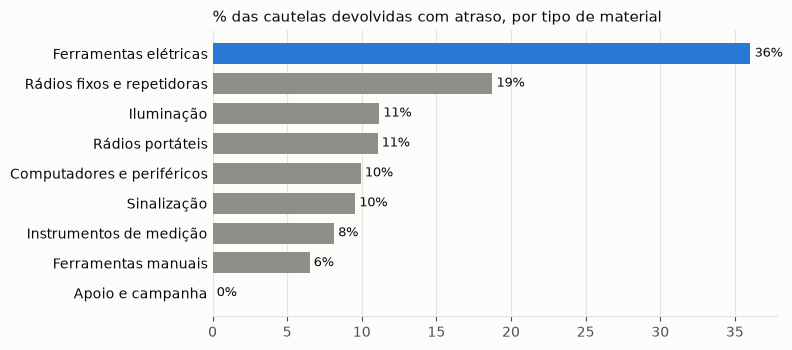

In [2]:
COR = {
    "serie": "#2a78d6",
    "contexto": "#8f8e89",
    "fundo": "#fcfcfb",
    "texto": "#0b0b0b",
    "texto2": "#52514e",
    "grade": "#e4e3df",
}
plt.rcParams.update(
    {
        "figure.facecolor": COR["fundo"],
        "axes.facecolor": COR["fundo"],
        "axes.edgecolor": COR["grade"],
        "axes.labelcolor": COR["texto2"],
        "xtick.color": COR["texto2"],
        "ytick.color": COR["texto"],
        "axes.spines.top": False,
        "axes.spines.right": False,
        "axes.spines.left": False,
        "font.size": 10,
    }
)

por_material = (
    cautelas.groupby("subcategoria")
    .agg(cautelas=("atrasada", "size"), taxa=("atrasada", "mean"))
    .query("cautelas >= 40")
    .sort_values("taxa")
)
destaque = "Ferramentas elétricas"
fig, ax = plt.subplots(figsize=(8, 3.6))
cores = [COR["serie"] if s == destaque else COR["contexto"] for s in por_material.index]
barras = ax.barh(por_material.index, 100 * por_material.taxa, height=0.7, color=cores)
ax.bar_label(
    barras,
    labels=[f"{100 * t:.0f}%" for t in por_material.taxa],
    padding=3,
    color=COR["texto"],
    fontsize=9,
)
ax.set_title(
    "% das cautelas devolvidas com atraso, por tipo de material",
    loc="left",
    color=COR["texto"],
    fontsize=11,
)
ax.xaxis.grid(True, color=COR["grade"], linewidth=0.8)
ax.set_axisbelow(True)
ax.tick_params(axis="y", length=0)
plt.tight_layout()
plt.show()

In [3]:
eletricas = cautelas[cautelas.subcategoria == "Ferramentas elétricas"]
(
    eletricas.assign(setor=eletricas.setor.where(eletricas.setor == "MANUT", "outros setores"))
    .groupby("setor")
    .agg(
        cautelas=("atrasada", "size"),
        taxa_de_atraso=("atrasada", "mean"),
        mediana_horas_com_a_pessoa=("horas_com_a_pessoa", "median"),
        mediana_dias_de_atraso=("dias_de_atraso", lambda d: d[d > 0].median()),
    )
    .round(2)
)

,cautelas,taxa_de_atraso,mediana_horas_com_a_pessoa,mediana_dias_de_atraso
setor,,,,
MANUT,198,0.45,103.26,17.88
outros setores,60,0.05,49.94,2.89


## 2. Quem atrasa: pessoa ou processo?

Um ranking cru pela taxa de atraso mistura duas coisas: a pessoa e o material que ela usa. Quem trabalha na Manutenção retira muita ferramenta elétrica, que atrasa para todo mundo. O módulo `almox.analise.cautela` separa as duas:

- **Taxa esperada** da pessoa: a média, nas cautelas dela, da taxa de atraso geral do tipo de material.
- **Intervalo de Wilson (95%)** para a taxa observada. A pessoa é apontada só se o limite inferior ficar acima da esperada, com pelo menos 20 cautelas. Com poucas cautelas o intervalo é largo, e 1 atraso em 2 não acusa ninguém.

In [4]:
pessoas = a2.atraso_por_pessoa(cautelas)
ingenuo = (pessoas.cautelas >= a2.MIN_CAUTELAS) & (
    pessoas.wilson_inferior > cautelas.atrasada.mean()
)
print(
    f"Método ingênuo (acima da média geral): {ingenuo.sum()} pessoas apontadas, "
    f"{(ingenuo & (pessoas.setor == 'MANUT')).sum()} da Manutenção."
)
print(
    f"Método ajustado pelo material: {pessoas.apontada.sum()} pessoas apontadas, "
    f"{(pessoas.apontada & (pessoas.setor == 'MANUT')).sum()} da Manutenção."
)
pessoas[pessoas.cautelas >= a2.MIN_CAUTELAS].head(10)[
    [
        "pessoa",
        "setor",
        "cautelas",
        "atrasadas",
        "observada",
        "esperada",
        "wilson_inferior",
        "wilson_superior",
        "apontada",
    ]
].round(3)

Método ingênuo (acima da média geral): 11 pessoas apontadas, 5 da Manutenção.
Método ajustado pelo material: 6 pessoas apontadas, 0 da Manutenção.


,pessoa,setor,cautelas,atrasadas,observada,esperada,wilson_inferior,wilson_superior,apontada
0,Priscila Barros,OPER,192,93,0.484,0.111,0.415,0.555,True
1,Yasmin Coutinho,OPER,218,100,0.459,0.111,0.394,0.525,True
2,Bruno Esteves,SEG,266,98,0.368,0.108,0.313,0.428,True
3,Samuel Valença,SEG,259,90,0.347,0.107,0.292,0.407,True
4,Natália Xavier,OPER,207,39,0.188,0.115,0.141,0.247,True
6,Sabrina Coutinho,OPER,239,41,0.172,0.111,0.129,0.224,True
7,Enzo Torres,MANUT,64,18,0.281,0.226,0.186,0.401,False
8,Júlia Nogueira,MANUT,65,16,0.246,0.195,0.158,0.363,False
9,Beatriz Pacheco,MANUT,76,20,0.263,0.218,0.177,0.372,False
10,Heitor Cavalcanti,MANUT,63,15,0.238,0.212,0.150,0.356,False


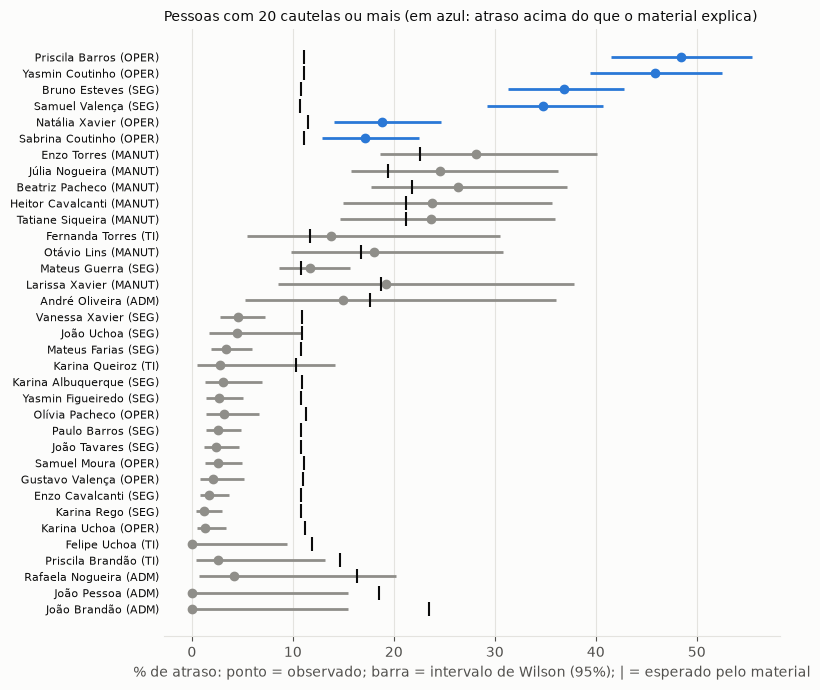

In [5]:
base = pessoas[pessoas.cautelas >= a2.MIN_CAUTELAS].sort_values("excesso")
fig, ax = plt.subplots(figsize=(8, 7))
for i, linha in enumerate(base.itertuples()):
    cor = COR["serie"] if linha.apontada else COR["contexto"]
    ax.hlines(i, 100 * linha.wilson_inferior, 100 * linha.wilson_superior, color=cor, linewidth=2)
    ax.plot(100 * linha.observada, i, "o", color=cor, markersize=6)
    ax.plot(100 * linha.esperada, i, "|", color=COR["texto"], markersize=10, markeredgewidth=1.5)
ax.set_yticks(
    range(len(base)),
    [f"{p} ({s})" for p, s in zip(base.pessoa, base.setor, strict=True)],
    fontsize=8,
)
ax.set_xlabel(
    "% de atraso: ponto = observado; barra = intervalo de Wilson (95%); | = esperado pelo material"
)
ax.set_title(
    "Pessoas com 20 cautelas ou mais (em azul: atraso acima do que o material explica)",
    loc="left",
    color=COR["texto"],
    fontsize=10,
)
ax.xaxis.grid(True, color=COR["grade"], linewidth=0.8)
ax.set_axisbelow(True)
ax.tick_params(axis="y", length=0)
plt.tight_layout()
plt.show()

## 3. Material que não voltou: cautelas de quem foi transferido

In [6]:
custos = pd.read_sql("SELECT codigo AS material, custo_unitario FROM core.material_tipo", banco)
perdidas = cautelas[cautelas.situacao == "NAO_LOCALIZADA"].merge(custos, on="material")
print(
    f"{len(perdidas)} unidades não localizadas no inventário; valor total "
    f"R$ {perdidas.custo_unitario.sum():,.2f} (fictício)."
)
perdidas[["material_nome", "bmp", "pessoa", "setor", "retirada_em", "custo_unitario"]]

3 unidades não localizadas no inventário; valor total R$ 4,900.00 (fictício).


,material_nome,bmp,pessoa,setor,retirada_em,custo_unitario
0,Lanterna tática recarregável,5116192,João Uchoa,SEG,2025-12-04 09:00:01-03:00,150.0
1,Multímetro digital,5426065,Larissa Xavier,MANUT,2026-01-20 09:00:27-03:00,250.0
2,Notebook de serviço,5384433,Tatiane Duarte,ADM,2026-03-09 09:00:43-03:00,4500.0


## 4. Situação na data de referência: cautelas vencidas em aberto

In [7]:
abertas = cautelas[cautelas.situacao == "EM_ABERTO"]
print(f"{len(abertas)} cautelas em aberto; {abertas.atrasada.sum()} com o prazo vencido:")
(
    abertas[abertas.atrasada].sort_values("dias_de_atraso", ascending=False)[
        ["material_nome", "bmp", "pessoa", "setor", "retirada_em", "dias_de_atraso"]
    ]
)

12 cautelas em aberto; 7 com o prazo vencido:


,material_nome,bmp,pessoa,setor,retirada_em,dias_de_atraso
5728,Furadeira de impacto 800 W,5079120,Tatiane Siqueira,MANUT,2026-08-14 13:12:01-03:00,10.36
5908,Cone de sinalização refletivo,5961765,Samuel Moura,OPER,2026-08-26 09:43:56-03:00,2.50
5968,Rádio portátil VHF RP-100,5051760,Karina Rego,SEG,2026-08-29 07:11:00-03:00,2.11
5974,Lanterna tática recarregável,5071032,Bruno Esteves,SEG,2026-08-29 17:31:46-03:00,1.68
5975,Rádio portátil VHF digital RP-200,5786020,Priscila Barros,OPER,2026-08-30 06:56:30-03:00,1.12
5870,Esmerilhadeira angular 1300 W,5195899,Enzo Torres,MANUT,2026-08-24 11:53:10-03:00,0.41
5875,Parafusadeira a bateria 12 V,5058627,Heitor Cavalcanti,MANUT,2026-08-24 15:12:44-03:00,0.27


## 5. Conferência com o gabarito do gerador

O gerador plantou três perfis de pontualidade (pontual, ocasional, reincidente). A análise acima não usou essa informação. Aqui ela é usada só para conferir.

In [8]:
import json

from almox.config import RAIZ_PROJETO

verdade = json.loads(
    (RAIZ_PROJETO / "data/gerado/gabarito_padroes.json").read_text(encoding="utf-8")
)["perfil_pontualidade"]
comparacao = pessoas.assign(perfil_real=pessoas.matricula.map(verdade), ingenuo=ingenuo)
pd.DataFrame(
    {
        "ajustado (apontadas)": comparacao[comparacao.apontada].perfil_real.value_counts(),
        "ingênuo (apontadas)": comparacao[comparacao.ingenuo].perfil_real.value_counts(),
        "total de pessoas": comparacao.perfil_real.value_counts(),
    }
).fillna(0).astype(int)

,ajustado (apontadas),ingênuo (apontadas),total de pessoas
perfil_real,,,
ocasional,2,2,8
pontual,0,5,28
reincidente,4,4,4


## Insights

1. **O atraso é, na maior parte, de processo, e está nas ferramentas elétricas da Manutenção.** Elas atrasam 45% das vezes na Manutenção e 5% nos outros setores, com mediana de 18 dias de atraso quando atrasam. O prazo padrão de 7 dias não combina com o trabalho da Manutenção. **Recomendação:** um prazo próprio para a Manutenção (ou cautela por ordem de serviço, com previsão de término), em vez de cobrar as pessoas.
2. **Um ranking ingênuo acusaria quem não deve.** Comparando com a média geral, 11 pessoas seriam apontadas, 5 delas pontuais da Manutenção. Ajustando pelo material e exigindo evidência estatística (Wilson), são 6: os 4 reincidentes que o gerador plantou (todos encontrados, sem ninguém dizer quem eram) e 2 ocasionais, que de fato atrasam mais do que o esperado. **Nenhuma pessoa pontual foi apontada.**
3. **Rádios funcionam bem no regime de turno.** 89% voltam no mesmo dia. O atraso dos rádios vem de quatro pessoas, e é conversa individual, não mudança de regra.
4. **Três unidades saíram com quem foi transferido** (lanterna, multímetro e notebook; R$ 4.900 fictícios). Todas foram cauteladas dias antes da transferência. **Recomendação:** conferir as cautelas em aberto no processo de desligamento. A regra DQ04 do schema `dq` já aponta esse caso automaticamente.
5. **Há 7 cautelas vencidas em aberto na data de referência**, e uma delas (a furadeira com 10 dias de atraso) é a mesma que a planilha da A1 dava como "localizada". A conferência e o histórico contam a mesma história por caminhos diferentes.